<a href="https://colab.research.google.com/github/kalex066/DataScience---ProyectoFinal/blob/main/EDA/CalidadNutricional.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#🥗 **Proyecto: Clasificación de Alimentos por su Calidad Nutricional**

**🎯 Objetivo:** Diseñar e implementar un modelo de clasificación capaz de categorizar automáticamente productos alimenticios según su perfil nutricional, proporcionando una calificación objetiva basada en datos técnicos.

**🔍 Problema que resuelve**: Muchos consumidores no saben interpretar la informacion de las etiquetas nutricionales de los alimentos, complejas y carecen de información estandarizada. Este proyecto aborda la falta de herramientas automatizadas que clasifiquen productos alimenticios de manera objetiva, reduciendo la fricción al momento de elegir alimentos saludables.

**📊 Dataset**: El estudio utiliza el dataset Comprehensive USDA FoodData Central, especificamete el archivo *comprehensive_foods_usda.csv*, el cual cuenta con más de 40,000 registros.

- **Calidad:** Fuente estandarizada y autorizada.
- **Atributos:** Macronutrientes (proteínas, grasas, carbohidratos), micronutrientes (vitaminas, minerales) y desglose detallado (fibra, azúcar, grasas saturadas).

**🎯 Variable Objetivo (Target)**: La variable se deriva de la columna health_score (escala 0-100). Para la tarea de clasificación, transformaremos esta puntuación continua en etiquetas categóricas:

|Rango de Score|Categoría de Calidad|
|:---|:---|
|0 - 40|Baja|
|41 - 70|Media|
|71 - 100|Alta|

Esto permitirá que el modelo aprenda a identificar las características distintivas de cada nivel de salud.

**🤖 Propuesta de Modelo**: Se utilizara un enfoque de aprendizaje supervisado utilizando métodos de clasificación.

Este proyecto se desarrolla como parte de la evaluación final de Bootcamp de DataScience.

**Diccionario de Datos:**

|**Columna**|**Tipo de dato**|**Descripción**|
|:---|:---|:---|
|fdc_id|Integer|Identificador único del producto en la base USDA.|
|food_name|String|Nombre estándar del producto alimenticio.|
|data_type|String|Clasificación del dato (Foundation, SR Legacy, Branded).|
|food_category|String|Categoría o grupo amplio de alimentos.|
|food_type|String|Clasificación simplificada (ej. Frutas, Carne, Lácteos)|
|calories|Float|Contenido energético por cada 100g (kcal).|
|protein_g|Float|Contenido de proteínas por cada 100g.|
|fat_g|Float|Contenido total de grasas por cada 100g.|
|carbs_g|Float|Contenido total de carbohidratos por cada 100g.|
|fiber_g|Float|Contenido de fibra dietética por cada 100g.|
|sugar_g|Float|Contenido de azúcares totales por cada 100g.|
|sodium_mg|Float|Contenido de sodio por cada 100g.|
|cholesterol_mg|Float|Contenido de colesterol por cada 100g.|
|saturated_fat_g|Float|Contenido de grasas saturadas por cada 100g.|
|vitamin_c_mg|Float|Contenido de Vitamina C por cada 100g.|
|calcium_mg|Float|Contenido de calcio por cada 100g.|
|iron_mg|Float|Contenido de hierro por cada 100g.|
|health_score|Float|Calificación personalizada de salud (0 a 100).|
|serving_size|Float|Tamaño de la porción estándar.|
|serving_unit|String|Unidad de medida de la porción (g, ml, etc.).|
|brand_owner|String|Empresa propietaria de la marca (si aplica).|
|brand_name|String|Nombre comercial del producto (si aplica).|
|ingredients|String|Lista de ingredientes detallada.|


**Detalle de Significado de Categorias de `data_type`**

**SR Legacy**(Standard Reference Legacy): Son los datos tradicionales y más antiguos del USDA. Se basan en análisis de laboratorio históricos y libros de referencia.Suelen ser alimentos básicos o crudos, sin procesar, no tienen marca comercial, ni lista de ingredientes, ni datos de empaquetado porque no son productos industriales.

**Foundation**: son datos derivados de estudios analíticos modernos financiados por el USDA para actualizar la base de datos antigua, tienen análisis detallados de nutrientes.

**Branded**: Son productos de consumo masivo con marca comercial (ej. una caja de cereales Kellog's), estos datos provienen de las etiquetas proporcionadas por los propios fabricantes.


# <font color='1890A3'>**SECCION 1. CARGA Y PRIMERA EXPLORACION**
**Cargar el dataset | head | tail | info | describe | shape** </font>

>## <font color='1890A3'>**Paso 1.1 Configuracion e importaciones** </font>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import warnings
import math
import re
import plotly.subplots as sp
from plotly.subplots import make_subplots
warnings.filterwarnings('ignore')

# Configuración de estilos
plt.rcParams.update({
    'figure.facecolor': '#0F0F1A', 'axes.facecolor': '#1A1A2E',
    'axes.edgecolor': '#444',      'axes.labelcolor': '#CCC',
    'xtick.color': '#AAA',         'ytick.color': '#AAA',
    'text.color': 'white',         'grid.color': '#333',
    'grid.linestyle': '--',        'legend.facecolor': '#1A1A2E',
    'legend.edgecolor': '#444',
})

template = dict(
    layout=dict(
        paper_bgcolor='#0F0F1A',
        plot_bgcolor='#1A1A2E',
        font=dict(color='white'),
        xaxis=dict(gridcolor='#333'),
        yaxis=dict(gridcolor='#333')
    )
)

# Paleta de colores para gráficos
PURPLE = '#6C3CE1'
TEAL   = '#00C9A7'
AMBER  = '#F59E0B'
RED    = '#E44D26'
BLUE   = '#3B82F6'
PINK   = '#EC4899'

> ## <font color='1890A3'>**Paso 1.2 Cargar el dataset**</font>

In [ ]:
df = pd.read_csv('/content/sample_data/comprehensive_foods_usda.csv')

print(f'Dataset cargado exitosamente!')
print(f'Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas')
print(f'Memoria aproximada: {df.memory_usage(deep=True).sum() / 1024:.0f} KB')
print(f'\nColumnas: {list(df.columns)}')

Dataset cargado exitosamente!
Dimensiones: 40000 filas x 24 columnas
Memoria aproximada: 33914 KB

Columnas: ['fdc_id', 'food_name', 'data_type', 'food_category', 'brand_owner', 'brand_name', 'ingredients', 'serving_size', 'serving_unit', 'household_serving', 'calories', 'carbs_g', 'calcium_mg', 'fat_g', 'protein_g', 'saturated_fat_g', 'vitamin_c_mg', 'fiber_g', 'iron_mg', 'sodium_mg', 'sugar_g', 'cholesterol_mg', 'health_score', 'food_type']


> ## <font color='1890A3'>**Paso 1.3 Primeras y Ultimas filas del Dataset**</font>

In [ ]:
print('=== Primeras 5 filas ===')
display(df.head())
print('\n=== Ultimas 5 filas ===')
display(df.tail())

=== Primeras 5 filas ===


,fdc_id,food_name,data_type,food_category,brand_owner,brand_name,ingredients,serving_size,serving_unit,household_serving,...,protein_g,saturated_fat_g,vitamin_c_mg,fiber_g,iron_mg,sodium_mg,sugar_g,cholesterol_mg,health_score,food_type
0,167782,"Abiyuch, raw",SR Legacy,Fruits and Fruit Juices,NaN,NaN,NaN,NaN,NaN,NaN,...,1.50,0.014,54.1,5.3,1.61,20.0,8.55,NaN,65,Fruits
1,171687,"Acerola juice, raw",SR Legacy,Fruits and Fruit Juices,NaN,NaN,NaN,NaN,NaN,NaN,...,0.40,0.068,1600.0,0.3,0.50,3.0,4.50,0.0,55,Fruits
2,171686,"Acerola, (west indian cherry), raw",SR Legacy,Fruits and Fruit Juices,NaN,NaN,NaN,NaN,NaN,NaN,...,0.40,0.068,1680.0,1.1,0.20,7.0,NaN,0.0,55,Fruits
3,168061,Acorn stew (Apache),SR Legacy,American Indian/Alaska Native Foods,NaN,NaN,NaN,NaN,NaN,NaN,...,6.81,1.280,0.0,0.7,1.00,130.0,0.34,20.0,50,Other
4,168992,"Agave, cooked (Southwest)",SR Legacy,American Indian/Alaska Native Foods,NaN,NaN,NaN,NaN,NaN,NaN,...,0.99,NaN,0.3,10.6,3.55,13.0,20.90,0.0,50,Other



=== Ultimas 5 filas ===


,fdc_id,food_name,data_type,food_category,brand_owner,brand_name,ingredients,serving_size,serving_unit,household_serving,...,protein_g,saturated_fat_g,vitamin_c_mg,fiber_g,iron_mg,sodium_mg,sugar_g,cholesterol_mg,health_score,food_type
39995,2664524,BEAN & RICE CHIPS,Branded,"Chips, Pretzels & Snacks","Beanfields, Inc.",BEANFIELDS,"BLACK BEANS, NAVY BEANS, BROWN RICE, ORGANIC B...",28.0,GRM,NaN,...,17.9,0.0,0.0,21.4,3.86,679.0,0.0,0.0,60,Grains
39996,1919754,"BEAN & RICE CHIPS WITH SEA SALT!, BLACK BEAN",Branded,"Chips, Pretzels & Snacks","Beanfields, Inc.",BEANFIELDS,"BLACK BEANS, BROWN RICE, ORGANIC BROWN RICE, S...",28.0,g,1 ONZ,...,17.9,0.0,0.0,21.4,3.21,339.0,0.0,0.0,70,Grains
39997,1937848,"BEAN & RICE CHIPS, BARBECUE",Branded,"Chips, Pretzels & Snacks","Beanfields, Inc.",BEANFIELDS,"BLACK BEANS, NAVY BEANS, BROWN RICE, ORGANIC B...",28.0,g,1 ONZ,...,17.9,0.0,0.0,21.4,3.86,446.0,0.0,0.0,70,Grains
39998,1905954,"BEAN & RICE CHIPS, BLACK BEAN",Branded,"Chips, Pretzels & Snacks","Beanfields, Inc.",BEANFIELDS,"BLACK BEANS, BROWN RICE, ORGANIC BROWN RICE, S...",28.0,g,1 ONZ,...,17.9,0.0,0.0,21.4,3.21,339.0,0.0,0.0,70,Grains
39999,2117023,"BEAN & RICE CHIPS, NACHO",Branded,"Chips, Pretzels & Snacks","Beanfields, Inc.",BEANFIELDS,"BLACK BEANS, NAVY BEANS, BROWN RICE, ORGANIC B...",28.0,g,1 ONZ,...,17.9,0.0,0.0,21.4,3.86,679.0,0.0,0.0,60,Grains


Se observan nulos en algunas columnas `brand_owner`, `brand_name`, `ingredients`, `serving_size`, y `serving_unit`en las primeras filas debido a que son alimentos de tipo "SR Legacy".

> ## <font color='1890A3'>**Paso 1.4 Estructura General del Dataset**</font>

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   fdc_id             40000 non-null  int64  
 1   food_name          40000 non-null  object 
 2   data_type          40000 non-null  object 
 3   food_category      39954 non-null  object 
 4   brand_owner        31383 non-null  object 
 5   brand_name         30254 non-null  object 
 6   ingredients        31656 non-null  object 
 7   serving_size       31842 non-null  float64
 8   serving_unit       31842 non-null  object 
 9   household_serving  30790 non-null  object 
 10  calories           39538 non-null  float64
 11  carbs_g            39411 non-null  float64
 12  calcium_mg         34215 non-null  float64
 13  fat_g              39713 non-null  float64
 14  protein_g          39747 non-null  float64
 15  saturated_fat_g    35014 non-null  float64
 16  vitamin_c_mg       229

El dataset tiene 40 000 filas y 23 columnas. Presencia de nulos en 18 columnas

Las columnas críticas como `calories`, `fat_g`, `protein_g`, y `sodium_mg` tienen más de 39,000 valores.

`vitamin_c_mg `(es la columna con más faltantes 22,940)

13 columnas tipo float y 2 tipo integer que no requieren conversión adicional.

9 columnas categoricas

> ## <font color='1890A3'>**Paso 1.5 Estadisticas Descriptivas del Dataset**</font>

In [ ]:
df.describe()
print('=== Columnas numericas ===')
display(df.describe())
print('\n=== Columnas categoricas ===')
display(df.describe(include='object'))

=== Columnas numericas ===


,fdc_id,serving_size,calories,carbs_g,calcium_mg,fat_g,protein_g,saturated_fat_g,vitamin_c_mg,fiber_g,iron_mg,sodium_mg,sugar_g,cholesterol_mg,health_score
count,4.000000e+04,31842.000000,39538.000000,39411.000000,34215.000000,39713.000000,39747.000000,35014.000000,22940.000000,33725.000000,34250.000000,3.938300e+04,35739.000000,34158.000000,40000.000000
mean,1.793461e+06,92.563962,308.159861,28.420500,106.091172,12.118343,8.260691,4.451546,24.138259,2.568491,2.389289,1.067233e+03,13.262690,62.575833,48.887250
std,8.964022e+05,100.581765,392.575965,47.614576,1327.632746,19.140351,10.668951,7.387522,1419.157682,5.662308,60.647733,2.895701e+04,36.323827,2141.337343,9.850912
min,1.675120e+05,0.000000,0.000000,-0.705000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,20.000000
25%,1.459896e+06,28.000000,85.000000,3.570000,5.000000,0.000000,0.420000,0.000000,0.000000,0.000000,0.030000,1.600000e+01,0.000000,0.000000,40.000000
50%,2.094756e+06,55.000000,250.000000,15.600000,29.000000,4.550000,5.130000,1.670000,0.000000,1.000000,0.980000,1.430000e+02,4.520000,0.000000,50.000000
75%,2.469605e+06,118.000000,404.000000,51.800000,98.000000,17.600000,12.500000,6.077500,5.200000,3.300000,2.280000,4.810000e+02,16.700000,38.000000,55.000000
max,2.752382e+06,5055.000000,37600.000000,6160.000000,150000.000000,1170.000000,760.000000,300.000000,210000.000000,588.000000,8930.000000,4.690000e+06,5560.000000,214000.000000,75.000000



=== Columnas categoricas ===


,food_name,data_type,food_category,brand_owner,brand_name,ingredients,serving_unit,household_serving,food_type
count,40000,40000,39954,31383,30254,31656,31842,30790,40000
unique,30900,3,240,5559,7174,24696,8,4226,9
top,2% REDUCED FAT MILK,Branded,"Fruit & Vegetable Juice, Nectars & Fruit Drinks",Beaver Street Fisheries Inc.,AHOLD,"REDUCED FAT MILK, VITAMIN A PALMITATE, VITAMIN...",g,1 Tbsp,Other
freq,386,31842,1937,706,421,153,18531,1881,15521


**Columnas Numericas**
Hay productos con 37600 calorías o 5560g de azúcar. Esto es físicamente imposible para una porción estándar de 100g.

`carbs_g` con valor negativo, min: -0.705. No puede haber carbohidratos negativos.

Hay diferencia de escalas entre los valores de las columnas'

**Columnas Categoricas**

Columnas `food_name` y `ingredients`tienen una "alta cardinalidad"con 30900  y 24696 valores únicos.

`food_type` (9 valores únicos), es la variable que mejor le permitirá al modelo generalizar el tipo de alimento.

El dataset está dominado por productos "Branded" (31,842 de 40,000 registros). El modelo aprenderá principalmente de productos de supermercado.

# <font color='1890A3'>**SECCION 2. LIMPIEZA DE DATOS**
**tipos | duplicados | inconsistencias | nulos | outliers** </font>

> ## <font color='1890A3'>**Paso 2.1 Verificar y corregir tipos de datos**</font>

In [ ]:
print('Tipos de Datos ANTES de limpiar:')
print(df.dtypes)
print()

Tipos de Datos ANTES de limpiar:
fdc_id                 int64
food_name             object
data_type             object
food_category         object
brand_owner           object
brand_name            object
ingredients           object
serving_size         float64
serving_unit          object
household_serving     object
calories             float64
carbs_g              float64
calcium_mg           float64
fat_g                float64
protein_g            float64
saturated_fat_g      float64
vitamin_c_mg         float64
fiber_g              float64
iron_mg              float64
sodium_mg            float64
sugar_g              float64
cholesterol_mg       float64
health_score           int64
food_type             object
dtype: object



Se mantendran los tipos originales para realizar EDA, luego en el pre procesamiento se realizaran algunas conversiones

> ## <font color='1890A3'>**Paso 2.2 Identificar consistencias en variables categoricas**</font>

In [ ]:
cat_features = ['food_name', 'data_type', 'food_category', 'brand_owner', 'brand_name', 'ingredients', 'serving_unit', 'household_serving',
'food_type']

for col in cat_features:
    print(f"--- Categorias en {col} ---")
    print(df[col].value_counts())
    print("\n")

--- Categorias en food_name ---
food_name
2% REDUCED FAT MILK                                                                  386
1% LOWFAT MILK                                                                       201
1% LOW FAT MILK                                                                       83
APPLE JUICE, APPLE                                                                    82
4% SMALL CURD COTTAGE CHEESE                                                          74
                                                                                    ... 
100% RUSSET JULIENNE POTATOES IN A CREAMY CHEESE SAUCE                                 1
100% RUSSET INSTANT MASHED POTATOES                                                    1
100% RUBY RED GRAPEFRUIT JUICE, RUBY RED                                               1
100% RUBY RED BLEND OF 3 JUICES FROM CONCENTRATE WITH ADDED INGREDIENTS, RUBY RED      1
100% SOURSOP JUICE WITH PULP, SOURSOP                               

In [ ]:
cat_features = ['data_type', 'food_type', 'food_category',
                'serving_unit', 'brand_owner', 'brand_name']

print('=== DIAGNÓSTICO DE CONSISTENCIA ====')
resumen = []
for col in cat_features:
    serie = df[col].dropna().astype(str)
    tiene_mayusculas  = serie.ne(serie.str.lower()).any()
    tiene_espacios    = serie.ne(serie.str.strip()).any()
    tiene_sufijos     = serie.str.contains(
        r'\b(inc|llc|corp|incorporated|corporation)\b',
        case=False, regex=True).any()
    tiene_abrev_unid  = serie.isin(['grm','gm','mlt','mll']).any() if col == 'serving_unit' else False
    n_unicos          = serie.nunique()

    resumen.append({
        'Columna':          col,
        'Únicos':           n_unicos,
        'Mayúsculas?':      '⚠️ Sí' if tiene_mayusculas else '✅ No',
        'Espacios extra?':  '⚠️ Sí' if tiene_espacios   else '✅ No',
        'Sufijos comerc.?': '⚠️ Sí' if tiene_sufijos    else '✅ No',
        'Abrev. unidades?': '⚠️ Sí' if tiene_abrev_unid else '✅ No',
    })

display(pd.DataFrame(resumen).set_index('Columna'))

print('\n=== TOP 5 VALORES POR COLUMNA ===')
for col in cat_features:
    vc = df[col].value_counts().head(5)
    print(f'\n{col}  ({df[col].nunique()} únicos):')
    print(vc.to_string())

def clean_base(text):
    if pd.isna(text): return np.nan
    return re.sub(r'\s+', ' ', str(text).lower().strip())

def clean_commercial(text):
    text = clean_base(text)
    if pd.isna(text): return np.nan
    text = re.sub(r"[.,\'`-]", ' ', text)
    text = re.sub(r'\b(inc|incorporated|llc|corp|corporation|sales)\b', '', text)
    return ' '.join(text.split())

# Columnas de normalización simple
for col in ['food_category', 'food_type', 'data_type']:
    df[col] = df[col].apply(clean_base)

# Columnas comerciales
df['brand_owner'] = df['brand_owner'].apply(clean_commercial)
df['brand_name']  = df['brand_name'].apply(clean_commercial)
df['ingredients']  = df['ingredients'].apply(clean_base)

# food_name: limpiar porcentajes, comas y métodos de cocción
df['food_name'] = (
    df['food_name']
    .str.strip().str.lower()
    .str.replace(r'^\d+%\s+', '', regex=True)
    .str.replace(r', (raw|cooked).*', '', regex=True)
    .str.replace(r',.*', '', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

# serving_unit: estandarizar abreviaturas
df['serving_unit'] = (
    df['serving_unit']
    .astype(str).str.lower().str.strip()
    .replace({'grm':'g','gm':'g','mlt':'ml','mll':'ml','nan':'unknown'})
    .replace(['','null','none'], 'unknown')
    .fillna('unknown')
)

# household_serving: eliminar aclaraciones entre paréntesis
df['household_serving'] = df['household_serving'].apply(
    lambda x: re.sub(r'\(.*?\)', '', clean_base(x)).strip()
    if pd.notna(x) else np.nan
)

print('\n=== VERIFICACIÓN POST-LIMPIEZA ===')
for col in cat_features:
    print(f'{col:20s}  únicos: {df[col].nunique():>5}  '
          f'nulos: {df[col].isnull().sum():>5}')



=== DIAGNÓSTICO DE CONSISTENCIA ====


,Únicos,Mayúsculas?,Espacios extra?,Sufijos comerc.?,Abrev. unidades?
Columna,,,,,
data_type,3,⚠️ Sí,✅ No,✅ No,✅ No
food_type,9,⚠️ Sí,✅ No,✅ No,✅ No
food_category,240,⚠️ Sí,⚠️ Sí,✅ No,✅ No
serving_unit,8,⚠️ Sí,✅ No,✅ No,✅ No
brand_owner,5559,⚠️ Sí,⚠️ Sí,⚠️ Sí,✅ No
brand_name,7174,⚠️ Sí,⚠️ Sí,⚠️ Sí,✅ No



=== TOP 5 VALORES POR COLUMNA ===

data_type  (3 únicos):
data_type
Branded       31842
SR Legacy      7793
Foundation      365

food_type  (9 únicos):
food_type
Other              15521
Snacks & Sweets     4971
Dairy               4756
Fruits              4566
Meat & Poultry      4211

food_category  (240 únicos):
food_category
Fruit & Vegetable Juice, Nectars & Fruit Drinks    1937
Cheese                                             1303
Candy                                              1185
Breads & Buns                                      1011
Chocolate                                           994

serving_unit  (8 únicos):
serving_unit
g      18531
GRM     6999
ml      4420
MLT     1434
MG       291

brand_owner  (5559 únicos):
brand_owner
Beaver Street Fisheries Inc.    706
Wal-Mart Stores, Inc.           562
Target Stores                   527
Ahold USA, Inc.                 496
GENERAL MILLS SALES INC.        481

brand_name  (7174 únicos):
brand_name
AHOLD       421
WEGMANS

`brand_owner`, `brand_name` y `food_category` con alta cardinalidad

In [ ]:
# ── reclasificación de food_type ─────────────────────────────────────────
def reclasificar_food_type(df):
    df = df.copy()
    reglas = {
        'milk|yogurt|cheese|butter|cream|dairy':            'dairy',
        'fish|shrimp|salmon|tuna|seafood|crustacean':       'seafood',
        'chicken|beef|pork|meat|turkey|bacon|sausage':      'meat & poultry',
        'apple|banana|berry|citrus|fruit|melon':            'fruits',
        'bread|rice|oat|wheat|grain|pasta|cereal|biscuit':  'grains',
        'soda|juice|tea|water|beverage|coffee|drink':       'beverages',
        'chocolate|candy|snack|dessert|sugar':              'snacks & sweets',
        'vegetable|salad|carrot|broccoli|spinach|legume':   'vegetables',
        'ketchup|mustard|mayonnaise|dip|salsa|sauce':       'condiments',
        'seasoning|marinade|salt|spice|honey':              'seasonings',
        'ice cream|frozen|dinner|entree|pizza':             'frozen',
    }
    mask_other = df['food_type'].isin(['other', 'others', ''])
    for patron, categoria in reglas.items():
        mask = (mask_other &
                df['food_category'].str.contains(patron, case=False, na=False))
        df.loc[mask, 'food_type'] = categoria
    return df

df = reclasificar_food_type(df)
print('\nDistribución food_type tras reclasificación:')
print(df['food_type'].value_counts())


Distribución food_type tras reclasificación:
food_type
snacks & sweets    6305
dairy              5208
other              5133
meat & poultry     4601
fruits             4566
grains             3894
vegetables         2697
beverages          1960
condiments         1882
seafood            1481
frozen             1254
seasonings         1019
Name: count, dtype: int64


> ## <font color='1890A3'>**Paso 2.3 Identificar y eliminar duplicados**</font>

In [ ]:
df_clean = df.copy()
df_clean = df.drop_duplicates(subset=['fdc_id'], keep='first')
n_total = len(df_clean)
n_dupes = df_clean.duplicated().sum()

print(f'Filas totales:           {n_total}')
print(f'Duplicados exactos:      {n_dupes} ({n_dupes/n_total*100:.1f}%)')

Filas totales:           40000
Duplicados exactos:      0 (0.0%)


> ## <font color='1890A3'>**Paso 2.4 Analisis de valores nulos**</font>

In [ ]:
null_report = pd.DataFrame({
    'Nulos':      df_clean.isnull().sum(),
    'Porcentaje': (df_clean.isnull().sum() / len(df_clean) * 100).round(2)
}).query('Nulos > 0').sort_values('Porcentaje', ascending=False)

null_report['Umbral'] = null_report['Porcentaje'].apply(
    lambda x: 'Imputar (< 30%)' if x < 30
    else ('Evaluar (30-50%)' if x < 50 else 'Eliminar columna (> 50%)')
)

print('=== Columnas con valores nulos ===')
display(null_report)
print(f"Valores nulos en el dataset: {df_clean.isnull().sum().sum()}")

=== Columnas con valores nulos ===


,Nulos,Porcentaje,Umbral
vitamin_c_mg,17060,42.65,Evaluar (30-50%)
brand_name,9746,24.36,Imputar (< 30%)
household_serving,9210,23.02,Imputar (< 30%)
brand_owner,8617,21.54,Imputar (< 30%)
ingredients,8344,20.86,Imputar (< 30%)
serving_size,8158,20.40,Imputar (< 30%)
fiber_g,6275,15.69,Imputar (< 30%)
cholesterol_mg,5842,14.60,Imputar (< 30%)
calcium_mg,5785,14.46,Imputar (< 30%)
iron_mg,5750,14.37,Imputar (< 30%)


Valores nulos en el dataset: 96288



**Estrategia de Imputación por Columna**

### Plan de Estrategia de Imputación de Valores Nulos de Columnas numericas

| Columna | Nulos | % | Estrategia | Justificación |
| :--- | :---: | :---: | :--- | :--- |
| **`vitamin_c_mg`** | 17060 | 42.65% | Cero | Se imputara con cero, no todos los alimentos contienen este nutriente|
| **`serving_size`** | 8158 | 20.40% | Mediana | Por food_type en primera instancia y luego por la mediana global si la categoria no tiene datos |
| **`fiber_g`** | 6275 | 15.69% | Cero | Se imputara con cero, no todos los alimentos contienen este nutriente |
| **`cholesterol_mg`** | 5842 | 14.60% | Cero | Se imputara con cero, no todos los alimentos contienen este nutriente |
| **`calcium_mg`** | 5785 | 14.46% | Cero | Se imputara con cero, no todos los alimentos contienen este nutriente |
| **`iron_mg`** | 5750 | 14.37% | Cero | MSe imputara con cero, no todos los alimentos contienen este nutriente |
| **`saturated_fat_g`** | 4986 | 12.46% | Cero | Se imputara con cero, no todos los alimentos contienen este nutriente |
| **`sugar_g`** | 4261 | 10.65% | Cero | Se imputara con cero, no todos los alimentos contienen este nutriente. |
| **`sodium_mg`** | 617 | 1.54% | Cero | Se imputara con cero, no todos los alimentos contienen este nutriente |
| **`carbs_g`** | 589 | 1.47% | Cero | Se imputara con cero, no todos los alimentos contienen este nutriente |
| **`calories`** | 462 | 1.16% | Eliminar | No existen alimentos con calorias cero y son pocos los registros nulos |
| **`fat_g`** | 287 | 0.72% | Cero | Se imputara con cero, no todos los alimentos contienen este nutriente |
| **`protein_g`** | 253 | 0.63% | Cero | Se imputara con cero, no todos los alimentos contienen este nutriente |



En las columnas de nutrientes, un valor nulo equivale a que el alimento no tenga ese nutriente, todas estas columnas se imputaran con cero, verificando que queden como numericas.

In [ ]:
# calorías (462 registros, 1.16%)
antes = len(df_clean)
df_clean = df_clean.dropna(subset=['calories'])
print(f'Filas eliminadas por calories nulo: {antes - len(df_clean)}')

Filas eliminadas por calories nulo: 462


In [ ]:
# nutrientes con cero
cols_nutrientes = [
    'protein_g', 'fat_g', 'carbs_g', 'sodium_mg', 'sugar_g',
    'saturated_fat_g', 'iron_mg', 'calcium_mg',
    'cholesterol_mg', 'fiber_g', 'vitamin_c_mg'
]
df_clean[cols_nutrientes] = df_clean[cols_nutrientes].fillna(0)
print(f'Nutrientes imputados con 0: {cols_nutrientes}')

Nutrientes imputados con 0: ['protein_g', 'fat_g', 'carbs_g', 'sodium_mg', 'sugar_g', 'saturated_fat_g', 'iron_mg', 'calcium_mg', 'cholesterol_mg', 'fiber_g', 'vitamin_c_mg']


In [ ]:
# serving_size por mediana de food_type con fallback a mediana global si la categoría tampoco tiene datos
mediana_global = df_clean['serving_size'].median()
mediana_por_tipo = df_clean.groupby('food_type')['serving_size'].transform('median')
df_clean['serving_size'] = (
    df_clean['serving_size']
    .fillna(mediana_por_tipo)
    .fillna(mediana_global)
)
print(f'serving_size imputado. Nulos restantes: {df_clean["serving_size"].isnull().sum()}')


serving_size imputado. Nulos restantes: 0


In [ ]:
null_final = df_clean.isnull().sum()
null_final = null_final[null_final > 0]
print(f'\nNulos restantes tras imputación:')
print(null_final.to_string() if len(null_final) > 0 else '  ✅ Ninguno en columnas de modelo')
print(f'\nShape final: {df_clean.shape}')


Nulos restantes tras imputación:
food_category          46
brand_owner          8511
brand_name           9631
ingredients          8300
household_serving    9104

Shape final: (39538, 24)


Me quedan los nulos categoricos

`food_category` se eliminara, son solo 46 registros de mas de 25000

`brand_owner`, `brand_name` e `ingredients` pueden ser porque pertenecen a SRLegacy que no tiene marca, o es una fruta que no tiene ingredientes, se imputara con unknown


In [ ]:
# Eliminar filas donde food_category sea nulo (NaN o None). Son solo 46 registros de 25000
df_clean = df_clean.dropna(subset=['food_category'])
print("Nulos en food_category después de eliminar:", df['food_category'].isna().sum())

Nulos en food_category después de eliminar: 0


In [ ]:
cols_null_categoric = ['brand_owner', 'brand_name', 'ingredients', 'household_serving']
df_clean[cols_null_categoric] = df_clean[cols_null_categoric].fillna('unknown')
print("Nulos tras la imputación:")
print(df_clean[cols_null_categoric + ['food_category']].isna().sum())

Nulos tras la imputación:
brand_owner          0
brand_name           0
ingredients          0
household_serving    0
food_category        0
dtype: int64


In [ ]:
#REporte final de Nulos
null_final = df_clean.isnull().sum()
null_final = null_final[null_final > 0]
print(f'\nNulos restantes tras imputación:')
print(null_final.to_string() if len(null_final) > 0 else '  ✅ Ninguno en columnas de modelo')
print(f'\nShape final: {df_clean.shape}')


Nulos restantes tras imputación:
  ✅ Ninguno en columnas de modelo

Shape final: (39492, 24)


> ## <font color='#1890A3'>**Paso 2.6 Identificar y Eliminar Outliers** </font>

Usualmente los outliers en valores alimenticios no son valores atipicos sino reales por la variedad de alimentos, se verificara si estan dentro o no de los rangos recomendados por USDA FoodData Central, que es de donde provienen los datos

In [ ]:
# Definición de límites físicos y lógicos por cada 100g. USDA FoodData Central (FDC)
limites_fisicos = {
    'calories':        (0, 900),    # Kcal por 100g
    'protein_g':       (0, 95),     # g por 100g
    'fat_g':           (0, 100),    # g por 100g
    'carbs_g':         (0, 100),    # g por 100g
    'fiber_g':         (0, 70),     # g por 100g
    'sugar_g':         (0, 100),    # g por 100g
    'sodium_mg':       (0, 40000),  # mg (Sal pura es ~39,000)
    'cholesterol_mg':  (0, 2000),   # mg
    'saturated_fat_g': (0, 100),    # g
    'vitamin_c_mg':    (0, 3000),   # mg
    'calcium_mg':      (0, 3000),   # mg
    'iron_mg':         (0, 100),    # mg
    'health_score':    (0, 100),    # Escala fija
    'serving_size':    (0.1, 5000)  # Tamaño de porción en gramos/ml
}

# Aplicación de los límites en el DataFrame
for col, (lo, hi) in limites_fisicos.items():
    if col in df_clean.columns:
        antes = df_clean[col].clip(lo, hi).ne(df_clean[col]).sum()
        df_clean[col] = df_clean[col].clip(lo, hi)
        if antes > 0:
            print(f'  {col:20s}: {antes} valores dentro del rango [{lo}, {hi}]')

  calories            : 1453 valores dentro del rango [0, 900]
  protein_g           : 17 valores dentro del rango [0, 95]
  fat_g               : 14 valores dentro del rango [0, 100]
  carbs_g             : 100 valores dentro del rango [0, 100]
  fiber_g             : 18 valores dentro del rango [0, 70]
  sugar_g             : 38 valores dentro del rango [0, 100]
  sodium_mg           : 33 valores dentro del rango [0, 40000]
  cholesterol_mg      : 34 valores dentro del rango [0, 2000]
  saturated_fat_g     : 3 valores dentro del rango [0, 100]
  vitamin_c_mg        : 6 valores dentro del rango [0, 3000]
  calcium_mg          : 46 valores dentro del rango [0, 3000]
  iron_mg             : 14 valores dentro del rango [0, 100]
  serving_size        : 15 valores dentro del rango [0.1, 5000]


La mayor cantidad esta en `calories` y `carbs` pero probablemente se debe a dulces, panes o productos con alto contenido calaorico. Todos se mantienen

> ## <font color='#1890A3'>**Paso 2.7 Eliminar Columnas Inncesarias** </font>
No se eliminara ninguna columna

> ## <font color='#1890A3'>**Paso 2.8 Resumen proceso de Limpieza** </font>

In [ ]:
print('------ RESUMEN DEL DATASET LIMPIO ------')
filas_finales, columnas_finales = df_clean.shape
print("---------------------------------------------------------")
print(f"Dimensiones Finales : {filas_finales} filas x {columnas_finales} columnas")
print(f"Valores Nulos Totales: {df_clean.isnull().sum().sum()} (¡Dataset 100% limpio!)")
print("---------------------------------------------------------")
print("Conteo de Variables por Tipo de Dato:")
print(df_clean.dtypes.value_counts())
print("---------------------------------------------------------")

------ RESUMEN DEL DATASET LIMPIO ------
---------------------------------------------------------
Dimensiones Finales : 39492 filas x 24 columnas
Valores Nulos Totales: 0 (¡Dataset 100% limpio!)
---------------------------------------------------------
Conteo de Variables por Tipo de Dato:
float64    13
object      9
int64       2
Name: count, dtype: int64
---------------------------------------------------------


In [ ]:
# Listas de control
cols_numéricas = ['calories', 'protein_g', 'fat_g', 'carbs_g', 'fiber_g', 'sugar_g', 'sodium_mg', 'cholesterol_mg', 'saturated_fat_g', 'vitamin_c_mg', 'calcium_mg', 'iron_mg', 'health_score', 'serving_size']
cols_categóricas = ['food_category', 'food_type', 'serving_unit', 'brand_owner', 'brand_name', 'ingredients', 'data_type']


# <font color='#1890A3'> **SECCION 3 EXPLORACION DE DATOS (EDA)**
**Univariante x2 | Multivariante x2 | Interpretacion** </font>

> ## <font color='#1890A3'>**Distribución del target health_score por data_type**</font>

**Objetivo:** Conocer si los tres tipos de dato (SR Legacy, Foundation, Branded) tienen distribuciones distintas del score.


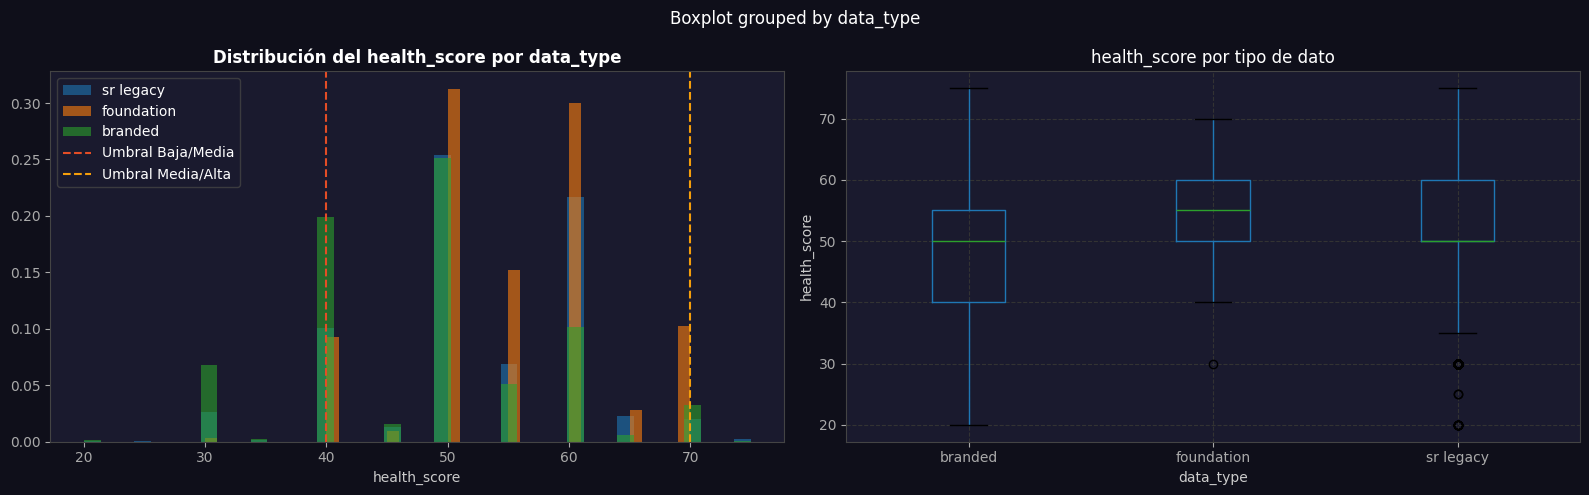

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for dt in df_clean['data_type'].unique():
    subset = df_clean[df_clean['data_type'] == dt]['health_score'].dropna()
    axes[0].hist(subset, bins=40, alpha=0.6, label=dt, density=True)
axes[0].axvline(40, color=RED,   linestyle='--', linewidth=1.5, label='Umbral Baja/Media')
axes[0].axvline(70, color=AMBER, linestyle='--', linewidth=1.5, label='Umbral Media/Alta')
axes[0].set_title('Distribución del health_score por data_type', fontweight='bold')
axes[0].set_xlabel('health_score')
axes[0].legend()

# Boxplot por data_type
df_clean.boxplot(column='health_score', by='data_type', ax=axes[1])
axes[1].set_title('health_score por tipo de dato')
axes[1].set_xlabel('data_type')
axes[1].set_ylabel('health_score')

plt.tight_layout()
plt.show()

>**Analisis**

`health_score` presenta una distribución diferenciada según la fuente del dato, donde la categoría "foundation" destaca por una mayor consistencia y valores superiores, concentrando su mediana cerca de los 55 puntos y con una menor variabilidad en comparación con las otras categorías.

Los alimentos "branded" como "sr legacy" muestran una mayor dispersión y una mayor presencia de valores atípicos (outliers) en el rango inferior (puntuaciones entre 20 y 30), lo que sugiere que estas fuentes incluyen una gama más amplia de productos con perfiles nutricionales heterogéneos, mientras que el umbral de 40 a 50 puntos actúa como el punto de mayor concentración de registros para los tres tipos de datos.

> ## <font color='#1890A3'>**Heatmap de correlación entre nutrientes y health_score**</font>

**Objetivo:** Conocer aber cuáles nutrientes tienen correlación real con el score.


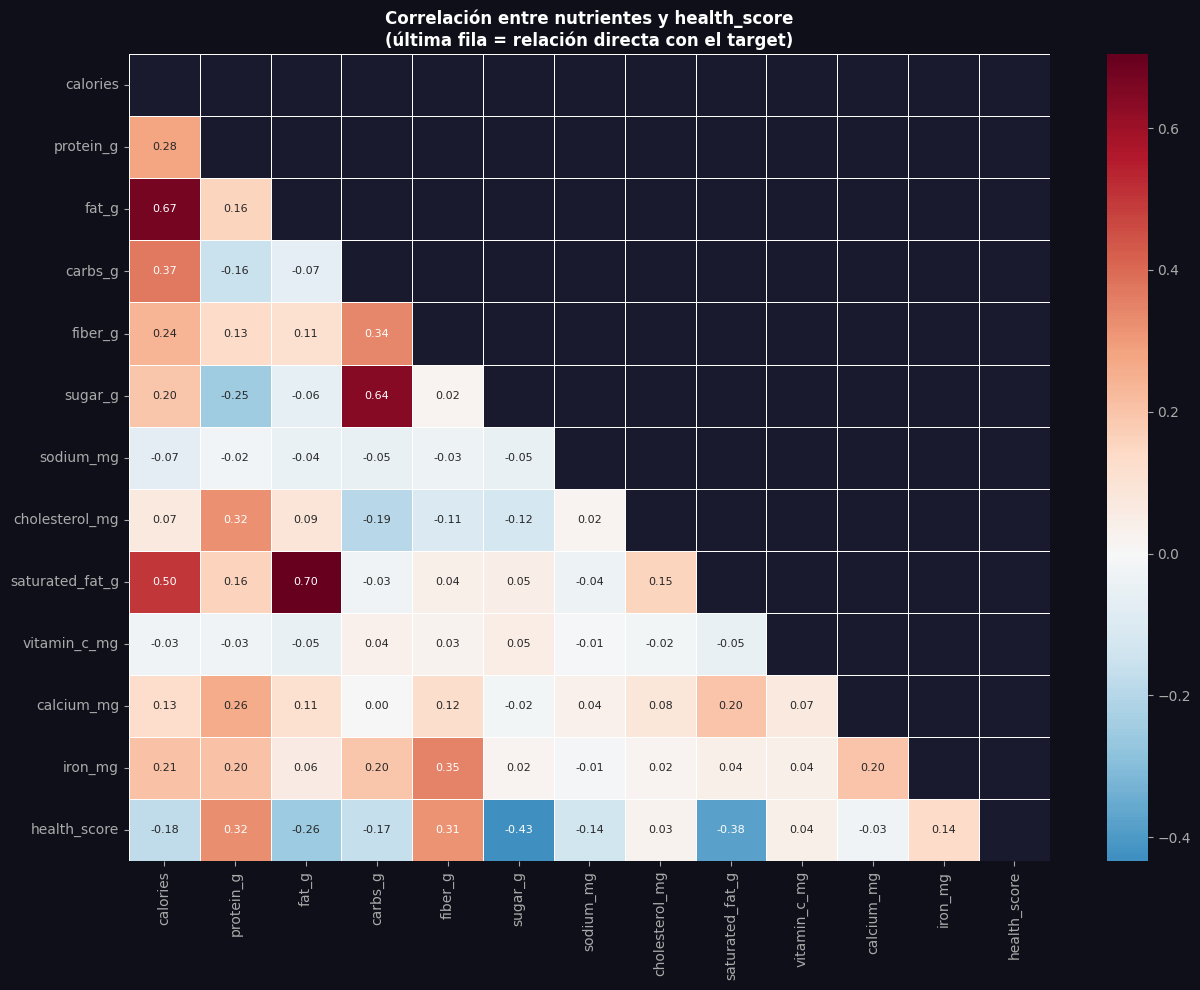

In [ ]:
cols_corr = ['calories', 'protein_g', 'fat_g', 'carbs_g', 'fiber_g', 'sugar_g', 'sodium_mg', 'cholesterol_mg', 'saturated_fat_g',
             'vitamin_c_mg', 'calcium_mg', 'iron_mg', 'health_score']

corr_matrix = df_clean[cols_corr].corr()
fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, mask=mask, linewidths=0.5, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Correlación entre nutrientes y health_score\n'
             '(última fila = relación directa con el target)',
             fontweight='bold')
plt.tight_layout()
plt.show()

>**Analisis**

`health_score` posee una relación inversa moderada con el contenido de azucar (-0.43) y grasas saturadas (-0.38), lo que indica que, a mayor presencia de estos componentes, la calificación de salud tiende a disminuir significativamente.

Por el contrario, se observa una correlación positiva moderada entre el puntaje de salud y la presencia de proteínas (0.32) y fibra (0.31), sugiriendo que estos nutrientes son los principales impulsores de una mejor puntaje en el `health_score`

Finalmente, el resto de las variables, como el calcio o la vitamina C, presentan una correlación cercana a cero, lo que implica que tienen un impacto insignificante o nulo en el cálculo actual del health_score.

> ## <font color='#1890A3'>**Boxplot de macronutrientes por categoría de calidad**</font>

**Objetivo:** muestra si las tres clases (Baja, Media, Alta) son separables visualmente en el espacio de los nutrientes.



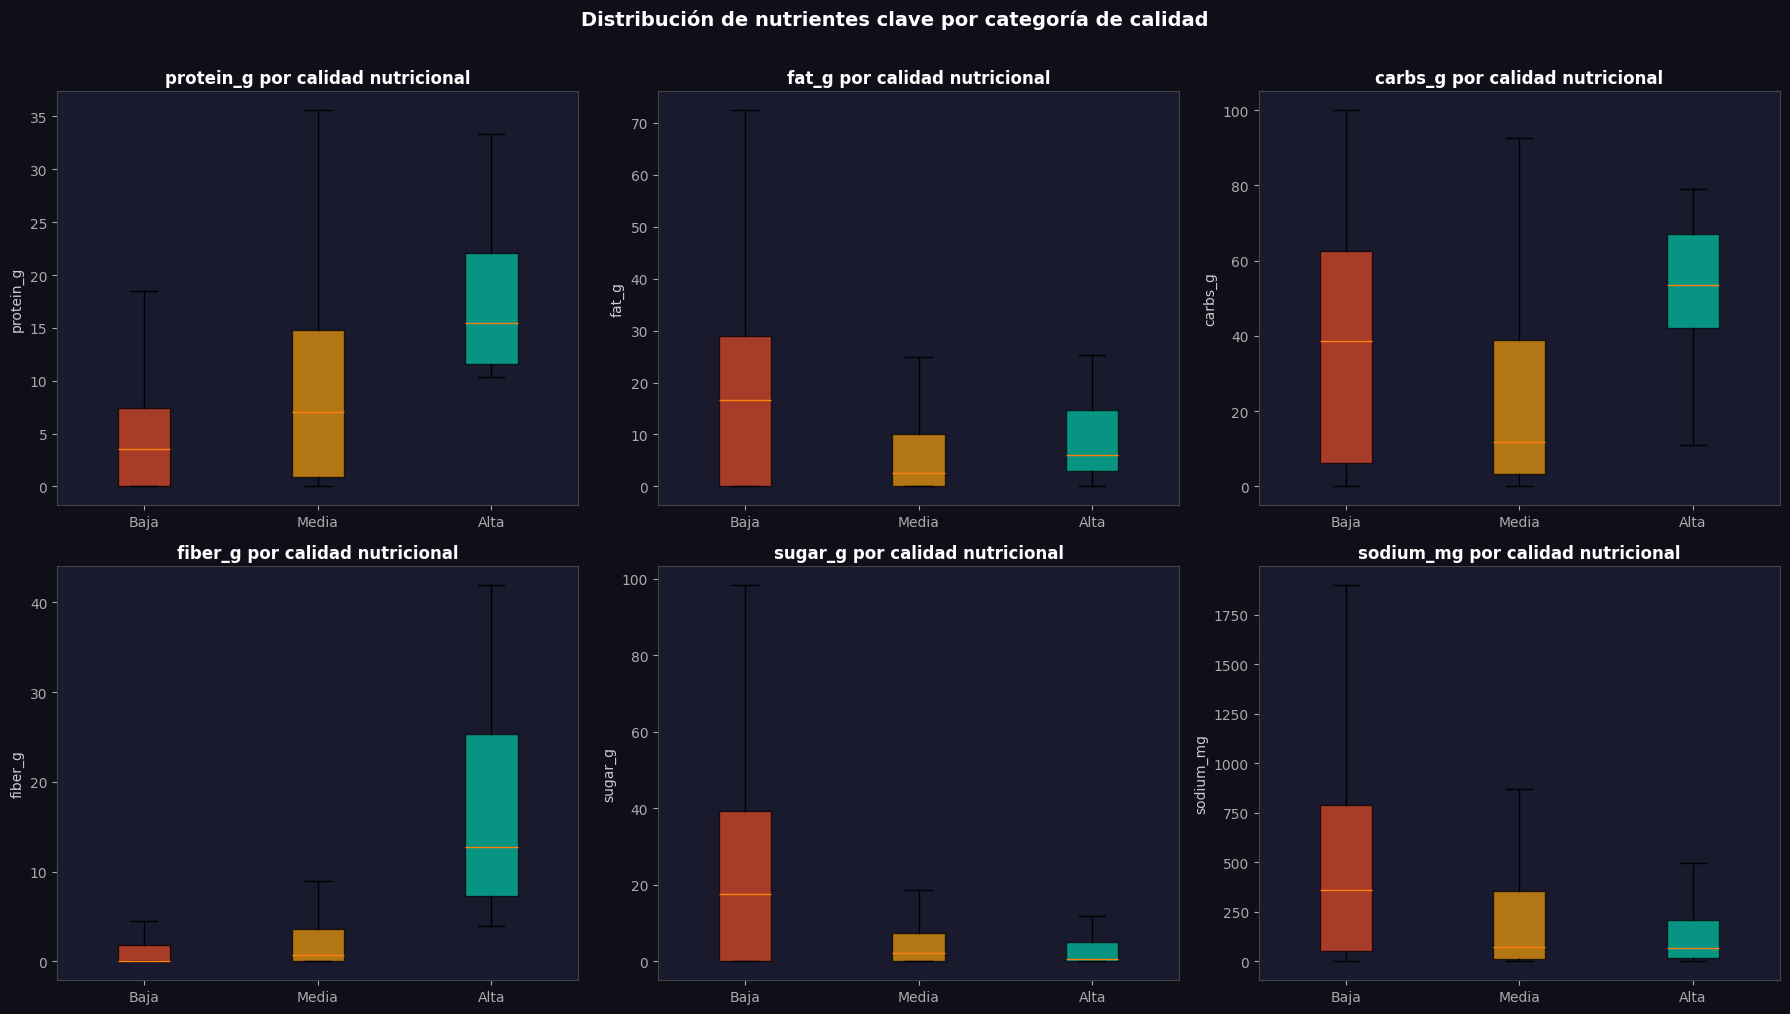

In [ ]:
# Crear el target categórico para esta visualización
df_clean['quality_cat'] = pd.cut(
    df_clean['health_score'],
    bins=[0, 40, 70, 100],
    labels=['Baja', 'Media', 'Alta']
)

nutrientes_key = ['protein_g', 'fat_g', 'carbs_g','fiber_g', 'sugar_g', 'sodium_mg']
orden = ['Baja', 'Media', 'Alta']
colores_cat = {'Baja': RED, 'Media': AMBER, 'Alta': TEAL}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, nutriente in enumerate(nutrientes_key):
    datos_plot = [
        df_clean[df_clean['quality_cat'] == cat][nutriente].dropna()
        for cat in orden
    ]
    bp = axes[i].boxplot(datos_plot, labels=orden, patch_artist=True,
                          showfliers=False)
    for patch, cat in zip(bp['boxes'], orden):
        patch.set_facecolor(colores_cat[cat])
        patch.set_alpha(0.7)
    axes[i].set_title(f'{nutriente} por calidad nutricional', fontweight='bold')
    axes[i].set_ylabel(nutriente)

plt.suptitle('Distribución de nutrientes clave por categoría de calidad',
             fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

>**Analisis**

El análisis de las distribuciones nutricionales por categoría de calidad revela que la proteína es el principal diferenciador positivo, mostrando un aumento progresivo en la mediana conforme mejora la calificación (Alta presenta los valores más consistentes y elevados), mientras que las grasas exhiben una relación inversa, donde los productos de Baja calidad muestran una dispersión y unos valores máximos mucho más altos, lo que sugiere una mayor presencia de grasas añadidas o menos saludables en dicho segmento.

Por su parte, los carbohidratos presentan un comportamiento más complejo y menos lineal, donde los productos de calidad Alta concentran sus valores en un rango intermedio-alto, posiblemente asociado a la presencia de fibra o carbohidratos complejos frente a los perfiles de baja calidad, que muestran una variabilidad extrema desde valores cercanos a cero hasta niveles muy altos.

La fibra actúa como un potente predictor de calidad, con un incremento drástico en la mediana y dispersión hacia los productos de calidad Alta, lo que sugiere que alimentos ricos en este componente son fundamentales en el segmento superior.

En contraste, el azúcar y el sodio presentan una correlación negativa evidente con la calidad, donde los productos de categoría Baja exhiben medianas y valores extremos significativamente superiores, consolidándose como factores críticos de penalización nutricional.